In [2]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=
)


In [3]:
service = QiskitRuntimeService()
print(service.backends())

qiskit_runtime_service.__init__:WARNING:2026-01-22 18:10:11,280: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-01-22 18:10:11,281: Loading instance: open-instance, plan: open


[<IBMBackend('ibm_fez')>, <IBMBackend('ibm_torino')>, <IBMBackend('ibm_marrakesh')>]


In [4]:
import json
import os
from datetime import datetime

from qiskit_ibm_runtime import QiskitRuntimeService

OUTDIR = "ibm_T1_mirror"
os.makedirs(OUTDIR, exist_ok=True)

service = QiskitRuntimeService()

timestamp = datetime.utcnow().isoformat() + "Z"

summary = {
    "timestamp_utc": timestamp,
    "qiskit_stack": "qiskit-ibm-runtime",
    "backends": {}
}

for backend in service.backends():
    name = backend.name
    print(f"Fetching T1 for {name}")

    try:
        props = backend.properties()
        if props is None:
            print(f"  No properties for {name}")
            continue

        t1_data = []

        for qubit, qubit_props in enumerate(props.qubits):
            for item in qubit_props:
                if item.name == "T1":
                    t1_data.append({
                        "qubit": qubit,
                        "value": item.value,
                        "unit": item.unit,
                        "date": item.date.isoformat()
                    })

        backend_record = {
            "backend_name": name,
            "num_qubits": backend.num_qubits,
            "last_update": props.last_update_date.isoformat(),
            "T1": t1_data
        }

        summary["backends"][name] = backend_record

        with open(os.path.join(OUTDIR, f"{name}_T1.json"), "w") as f:
            json.dump(backend_record, f, indent=2)

    except Exception as exc:
        print(f"  Failed for {name}: {exc}")

with open(os.path.join(OUTDIR, "ALL_T1.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("✔ T1 mirroring complete")


qiskit_runtime_service.__init__:WARNING:2026-01-22 18:11:22,653: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
/tmp/ipykernel_54999/3271716587.py:12: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp = datetime.utcnow().isoformat() + "Z"
qiskit_runtime_service.backends:WARNING:2026-01-22 18:11:22,656: Loading instance: open-instance, plan: open


Fetching T1 for ibm_fez
Fetching T1 for ibm_torino
Fetching T1 for ibm_marrakesh
✔ T1 mirroring complete


In [55]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTDIR = "ibm_T1_mirror"   # folder with mirrored data
PLOTDIR = "t1_plots"
os.makedirs(PLOTDIR, exist_ok=True)

all_data = []

for filename in os.listdir(OUTDIR):
    if not filename.endswith(".json"):
        continue

    path = os.path.join(OUTDIR, filename)
    with open(path, "r") as f:
        data = json.load(f)

    # -------------------------
    # Detect format
    # -------------------------
    if "backend_name" in data:
        backend_name = data["backend_name"]
        t1_list = data.get("T1", [])

    elif "backends" in data:
        # Format B: ALL_T1.json
        for backend_name, backend_data in data["backends"].items():
            t1_list = backend_data.get("T1", [])
            for q in t1_list:
                all_data.append({
                    "backend": backend_name,
                    "qubit": q["qubit"],
                    "t1_s": q["value"]
                })
        continue

    else:
        print(f"Unknown format: {filename}")
        continue

    # -------------------------
    # Extract T1
    # -------------------------
    for q in t1_list:
        all_data.append({
            "backend": backend_name,
            "qubit": q["qubit"],
            "t1_s": q["value"]
        })

df = pd.DataFrame(all_data)

df = df.dropna()
df = df[df["t1_s"] > 0]

print("Loaded devices:", df["backend"].nunique())
print("Total qubits:", len(df))

# -------------------------
# Plot 1: histogram all devices
# -------------------------
plt.figure(figsize=(12, 6))
plt.hist(df["t1_s"], bins=80)
plt.title("T1 Distribution Across All IBM Devices")
plt.xlabel("T1 (us)")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(PLOTDIR, "t1_all_devices_hist.png"))
plt.close()

# -------------------------
# Plot 2: boxplot by device
# -------------------------
plt.figure(figsize=(14, 7))
order = df.groupby("backend")["t1_s"].median().sort_values().index

plt.boxplot(
    [df[df["backend"] == b]["t1_s"].values for b in order],
    labels=order,
    showfliers=False
)

plt.xticks(rotation=90)
plt.title("T1 Boxplot by IBM Device")
plt.ylabel("T1 (us)")
plt.tight_layout()
plt.savefig(os.path.join(PLOTDIR, "t1_by_device_boxplot.png"))
plt.close()

print("Plots saved in:", PLOTDIR)


Loaded devices: 3
Total qubits: 890
Plots saved in: t1_plots


/tmp/ipykernel_55881/3615729981.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


In [56]:
df

,backend,qubit,t1_s
0,ibm_fez,0,54.830748
1,ibm_fez,1,221.596831
2,ibm_fez,2,263.951354
3,ibm_fez,3,201.666170
4,ibm_fez,4,215.923642
...,...,...,...
885,ibm_marrakesh,151,183.291393
886,ibm_marrakesh,152,267.985660
887,ibm_marrakesh,153,205.775150
888,ibm_marrakesh,154,216.245734


In [57]:
df = df[df['backend'] == 'ibm_torino']

In [58]:
df

,backend,qubit,t1_s
156,ibm_torino,0,202.468540
157,ibm_torino,1,216.080081
158,ibm_torino,2,144.671149
159,ibm_torino,3,193.804864
160,ibm_torino,4,166.435915
...,...,...,...
729,ibm_torino,128,305.164719
730,ibm_torino,129,238.570150
731,ibm_torino,130,272.569741
732,ibm_torino,131,275.166034


In [59]:
import numpy as np
import pandas as pd
import scipy.stats as st

# -----------------------------
# Load your data
# -----------------------------
# df["t1_s"] should contain all T1 values
# Example:
# df = pd.read_csv("all_t1.csv")
# x = df["t1_s"].values

x = df["t1_s"].values
x = x[~np.isnan(x)]
x = x[x > 0]

# -----------------------------
# Candidate distributions
# -----------------------------
dist_list = [
    st.norm,
    st.lognorm,
    st.gamma,
    st.invgamma,
    st.weibull_min,
    st.expon
]

results = []

for dist in dist_list:
    # Fit distribution
    params = dist.fit(x)

    # Log-likelihood
    ll = np.sum(dist.logpdf(x, *params))

    # Number of parameters
    k = len(params)

    # AIC/BIC
    aic = 2*k - 2*ll
    bic = k*np.log(len(x)) - 2*ll

    # KS test
    ks_stat, ks_p = st.kstest(x, dist.name, args=params)

    results.append({
        "dist": dist.name,
        "params": params,
        "log_likelihood": ll,
        "AIC": aic,
        "BIC": bic,
        "KS_stat": ks_stat,
        "KS_p": ks_p
    })

res_df = pd.DataFrame(results)
res_df = res_df.sort_values("AIC")
print(res_df[["dist", "AIC", "BIC", "KS_stat", "KS_p"]])


          dist          AIC          BIC   KS_stat          KS_p
4  weibull_min  2988.931233  2999.681722  0.043158  6.881396e-01
0         norm  2999.096605  3006.263598  0.065480  1.953959e-01
1      lognorm  3001.096826  3011.847315  0.065480  1.953921e-01
2        gamma  3006.180221  3016.930710  0.077515  7.755064e-02
3     invgamma  3013.811880  3024.562369  0.085485  3.859075e-02
5        expon  3285.719090  3292.886083  0.305924  1.354994e-22


Weibull-min parameters: (np.float64(6.734192839966301), np.float64(-203.84771214165877), np.float64(410.1025545735889))
KS statistic: 0.0431583607608354
KS p-value: 0.688139600924273


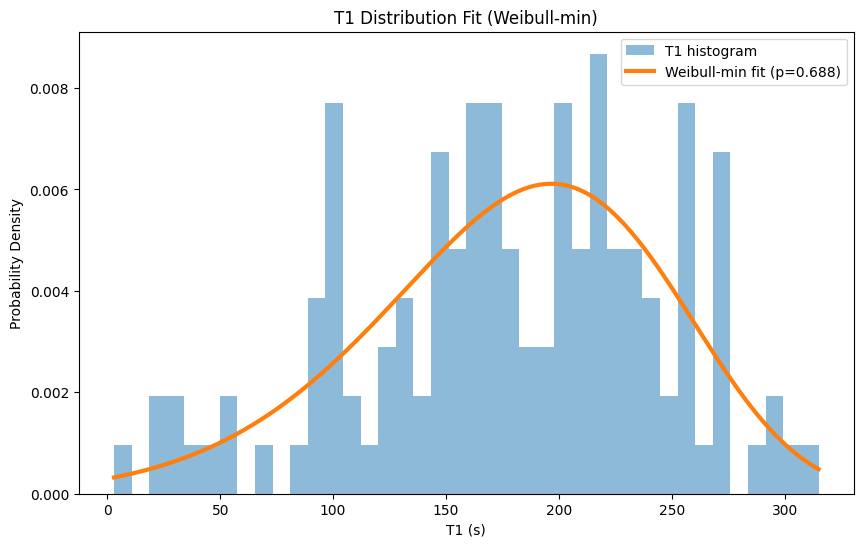

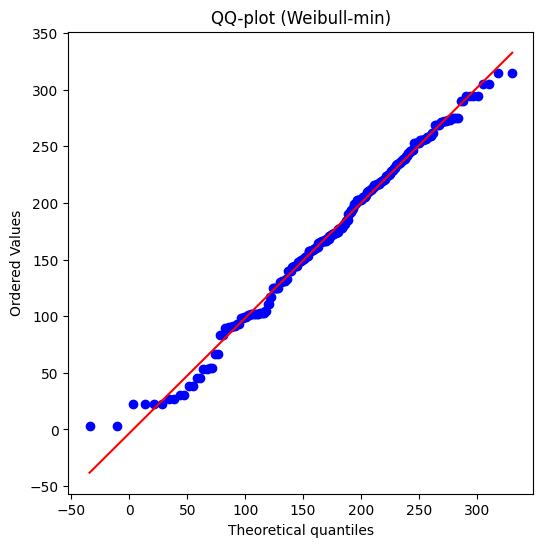

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

# -----------------------------
# Load your data
# -----------------------------
# x should be your T1 list (seconds)
# Example:
# x = np.loadtxt("t1_values.csv")

x = df["t1_s"].values
x = x[~np.isnan(x)]
x = x[x > 0]

# -----------------------------
# Fit Weibull-min distribution
# -----------------------------
dist = st.weibull_min
params = dist.fit(x)

# Print fitted parameters
print("Weibull-min parameters:", params)

# KS test
ks_stat, ks_p = st.kstest(x, dist.name, args=params)
print("KS statistic:", ks_stat)
print("KS p-value:", ks_p)

# -----------------------------
# Plot histogram + fitted PDF
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Histogram
count, bins, _ = ax.hist(x, bins=40, density=True, alpha=0.5, label="T1 histogram")

# PDF
xs = np.linspace(x.min(), x.max(), 1000)
pdf = dist.pdf(xs, *params)

ax.plot(xs, pdf, lw=3, label=f"Weibull-min fit (p={ks_p:.3f})")

ax.set_xlabel("T1 (s)")
ax.set_ylabel("Probability Density")
ax.set_title("T1 Distribution Fit (Weibull-min)")
ax.legend()
plt.show()

# -----------------------------
# QQ-plot for verification
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 6))
st.probplot(x, dist=dist, sparams=params, plot=ax)
ax.set_title("QQ-plot (Weibull-min)")
plt.show()
